# XGBoost
## Predict wether a telecom customer will churn or not

# Imports

### Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset


In [3]:
df = pd.read_csv("../Datasets/TelecomChurn.csv")

Variable Breakdown

    STATE: 51 Unique States in United States of America
    Account Length. Length of The Account
    Area Code 415 relates to San Francisco,408 is of San Jose and 510 is of City of Okland
    International Plan Yes Indicate International Plan is Present and No Indicates no subscription for Internatinal Plan
    Voice Mail Plan Yes Indicates Voice Mail Plan is Present and No Indicates no subscription for Voice Mail Plan
    Number vmail messages Number of Voice Mail Messages ranging from 0 to 50
    Total day minutes Total Number of Minutes Spent By Customers in Morning
    Total day calls Total Number of Calls made by Customer in Morning.
    Total day charge Total Charge to the Customers in Morning.
    Total eve minutesTotal Number of Minutes Spent By Customers in Evening
    Total eve calls Total Number of Calls made by Customer in Evening.
    Total eve charge Total Charge to the Customers in Morning.
    Total night minutes Total Number of Minutes Spent By Customers in the Night.
    Total night calls Total Number of Calls made by Customer in Night.
    Total night charge Total Charge to the Customers in Night.



# EDA

In [4]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

### == > There're no missing values in the dataset
### == > ["state", "international plan", "voice mail plan"] need to be encoded
### == > "churn" can be encoded

In [6]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


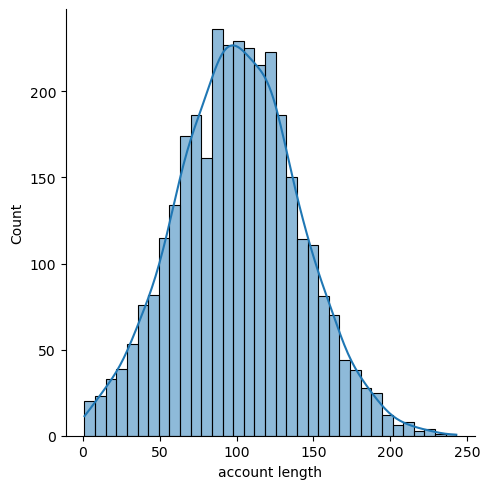

In [7]:
sns.displot(df["account length"], kde=True)

In [8]:
df.describe(exclude="number")

,state,phone number,international plan,voice mail plan,churn
count,3333,3333,3333,3333,3333
unique,51,3333,2,2,2
top,WV,382-4657,no,no,False
freq,106,1,3010,2411,2850


In [9]:
df.nunique()

state                       51
account length             212
area code                    3
phone number              3333
international plan           2
voice mail plan              2
number vmail messages       46
total day minutes         1667
total day calls            119
total day charge          1667
total eve minutes         1611
total eve calls            123
total eve charge          1440
total night minutes       1591
total night calls          120
total night charge         933
total intl minutes         162
total intl calls            21
total intl charge          162
customer service calls      10
churn                        2
dtype: int64

Text(0.5, 1.0, 'Correlation Heatmap')

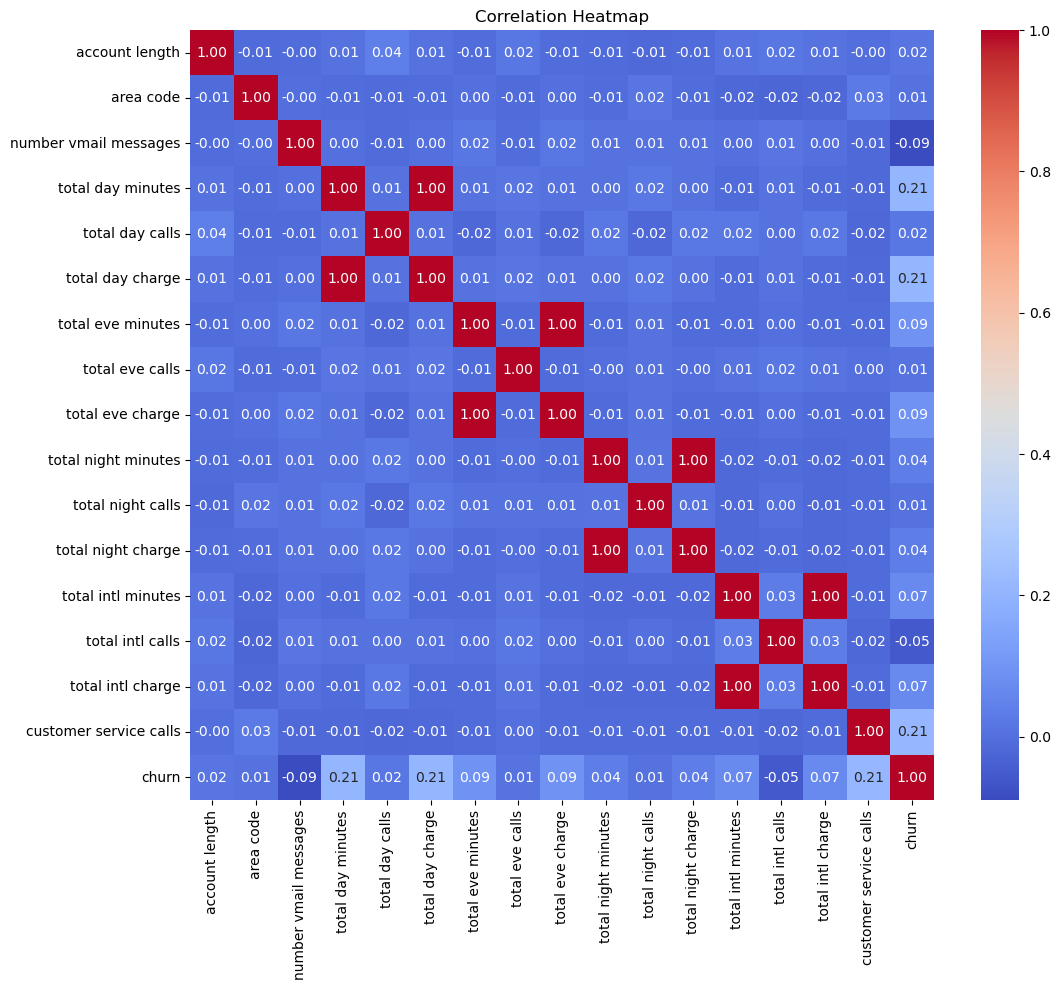

In [10]:
# check for correlations between numerical features
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

In [11]:
churnscounts = df["churn"].value_counts()
churnscounts

churn
False    2850
True      483
Name: count, dtype: int64

In [12]:
churnscounts[True]/df['churn'].count()

np.float64(0.14491449144914492)

In [13]:
chruns=df[df.churn==1]
noChruns=df[df.churn==0]

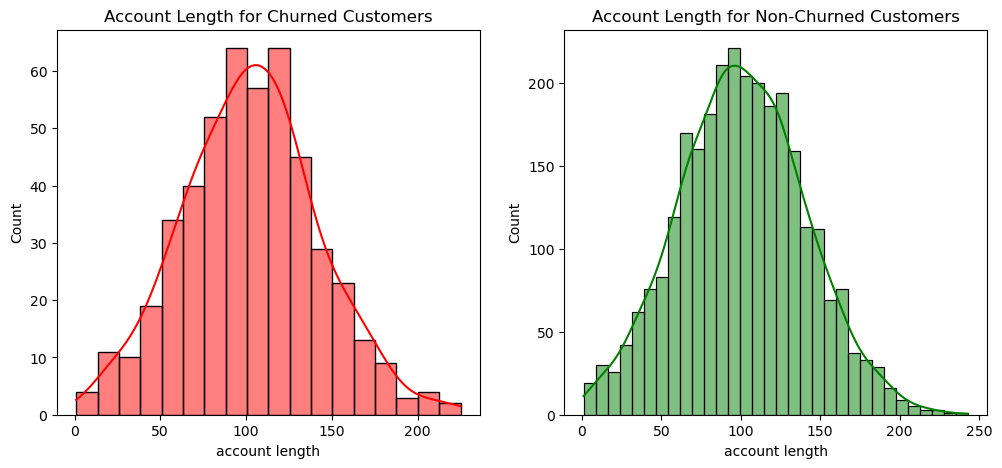

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(chruns["account length"], kde=True, ax=axes[0], color="red")
axes[0].set_title("Account Length for Churned Customers")
sns.histplot(noChruns["account length"], kde=True, ax=axes[1], color="green")
axes[1].set_title("Account Length for Non-Churned Customers")
plt.show()

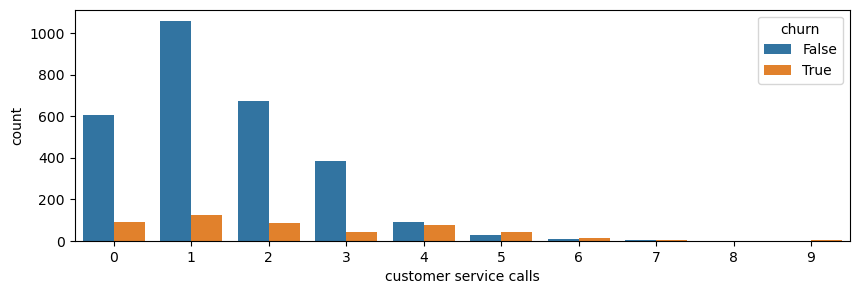

In [15]:
fig, axes = plt.subplots(figsize=(10, 3))
axes = sns.countplot(x="customer service calls", hue="churn", data=df)

## Preprocessing

In [16]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [17]:
columns2drop = ["phone number", "total day charge", "total eve charge", "total night charge", "total intl charge"]
df=df.drop(columns=columns2drop, axis=1)

In [18]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()

df["churn"] = enc.fit_transform(df["churn"])

In [19]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

columns2drop = ["international plan", "voice mail plan", "state"]

encoded_cols = encoder.fit_transform(df[columns2drop])
encoder.categories_

[array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA',
        'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME',
        'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM',
        'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
        'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'], dtype=object)]

In [20]:
feature_name = encoder.get_feature_names_out(columns2drop)
encoded_df = pd.DataFrame(encoded_cols, columns=feature_name)
df2 = pd.concat([df, encoded_df], axis=1)
df2 = df2.drop(columns=columns2drop, axis=1)

In [21]:
y=df2["churn"]
x=df2.drop(columns=["churn"], axis=1)

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## Train a XGBoost model

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [24]:
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

def evaluate_model(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results["Model"].append(model_name)
    results["Accuracy"].append(acc)
    results["Precision"].append(prec)
    results["Recall"].append(rec)
    results["F1 Score"].append(f1)

results_df = pd.DataFrame(results)
results_df

def print_evaluation(model, x_test, y_test):
    y_pred = model.predict(x_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    

In [26]:
# XGBoost
""" import xgboost as xgb

xgb_rf_cl = xgb.XGBRFClassifier(random_state=42)
xgb_rf_cl.fit(x_train, y_train)
y_pred = xgb_rf_cl.predict(x_test)
print_evaluation(xgb_rf_cl, x_test, y_test)  """

' import xgboost as xgb\n\nxgb_rf_cl = xgb.XGBRFClassifier(random_state=42)\nxgb_rf_cl.fit(x_train, y_train)\ny_pred = xgb_rf_cl.predict(x_test)\nprint_evaluation(xgb_rf_cl, x_test, y_test)  '